# Imports Libraries

In [96]:
import pandas as pd
import seaborn as sns
import seaborn as sns
import numpy as np
import os 
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score 

# LOAD DATA

In [97]:
# df = pd.read_csv(   
#     r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\heatwave_risk_engineered.csv"
# )
df = pd.read_csv(   
    r"D:\ClimateGuardAI\datasets\engineered\heatwave_risk_engineered.csv"
)
print(df.head())

   latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
0     24.57      77.72                 27.5      20.5          281   
1     23.33      77.80                 27.5      15.5          287   
2     22.07      78.93                 26.3      18.4          317   
3     21.86      77.93                 25.6      16.9          297   
4     22.75      77.72                 27.2      16.2          274   

   pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
0         1008        0.0        67     26                29.7  ...   
1         1008        0.0        70     19                30.0  ...   
2         1009        0.0        70     51                28.2  ...   
3         1009        0.0        76     65                27.6  ...   
4         1009        0.0        74     82                29.9  ...   

   season_Monsoon  season_Post_Monsoon  season_Summer  season_Winter  Cluster  \
0             1.0                  0.0            0.0            0.0   

# FEATURE ENGINEERING (YOUR ORIGINAL SCORING SYSTEM)

In [98]:
profile_score = {
    'Flood-Prone Climate': 35,
    'Heatwave-Prone Climate': 30,
    'Pollution-Prone Climate': 25,
    'Moderate Climate': 10
}

rainfall_score = {
    'Low': 5,
    'Medium': 20,
    'High': 35
}

heatwave_score = {
    'Safe': 5,
    'Warning': 20,
    'Critical': 35
}

anomaly_score = {
    'Normal': 5,
    'Anomalous Weather': 20
}
new_cols = pd.DataFrame({
    'profile_score': df['Climate_Profile'].map(profile_score),
    'rainfall_score': df['rainfall_risk'].map(rainfall_score),
    'heatwave_score': df['heatwave_risk'].map(heatwave_score),
    'anomaly_score': df['Status'].map(anomaly_score)
})

df = pd.concat([df, new_cols], axis=1)

# TARGET VARIABLE (ML LEARNING TARGET)

In [99]:
# df['Climate_Risk_Score'] = (
#       df['profile_score']
#     + df['rainfall_score']
#     + df['heatwave_score']
#     + df['anomaly_score']
# ).clip(0, 100)


df['Climate_Risk_Score'] = (
    df['profile_score'].fillna(0) +
    df['rainfall_score'].fillna(0) +
    df['heatwave_score'].fillna(0) +
    df['anomaly_score'].fillna(0)
).clip(0, 100)

In [100]:
X = df[[
    'profile_score',
    'rainfall_score',
    'heatwave_score',
    'anomaly_score'
]]

y = df['Climate_Risk_Score']

# TRAIN TEST SPLIT

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODEL (BASE)


In [102]:
rf = RandomForestRegressor(random_state=42)

# HYPERPARAMETER TUNING (GRID SEARCH)

In [103]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Combine X_train and y_train to drop NaNs consistently
train_data = pd.concat([X_train, y_train], axis=1)
train_data.dropna(inplace=True)

X_train_cleaned = train_data.drop(columns=y_train.name)
y_train_cleaned = train_data[y_train.name]

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_cleaned, y_train_cleaned)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

# BEST MODEL

In [104]:
best_model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


# PREDICTION + EVALUATION

In [105]:
# Combine X_test and y_test to drop NaNs consistently
test_data = pd.concat([X_test, y_test], axis=1)
test_data.dropna(inplace=True)

X_test_cleaned = test_data.drop(columns=y_test.name)
y_test_cleaned = test_data[y_test.name]

y_pred = best_model.predict(X_test_cleaned)

print("\nMAE:", mean_absolute_error(y_test_cleaned, y_pred))
print("R2 Score:", r2_score(y_test_cleaned, y_pred))


MAE: 4.219409282700582e-05
R2 Score: 0.9999999027683857


# RISK LEVEL FUNCTION

In [106]:
def risk_level(score):
    if score < 30:
        return 'Low'
    elif score < 60:
        return 'Medium'
    elif score < 80:
        return 'High'
    else:
        return 'Critical'

# NEW SAMPLE PREDICTION

In [107]:
new_data = pd.DataFrame({
    'profile_score': [30],
    'rainfall_score': [35],
    'heatwave_score': [20],
    'anomaly_score': [20]
})

pred = best_model.predict(new_data)

print("\nPredicted Climate Risk Score:", pred[0])
print("Risk Level:", risk_level(pred[0]))


Predicted Climate Risk Score: 75.0
Risk Level: High


# SAVE MODEL

In [108]:
save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, "climate_risk_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print("\nModel saved successfully!")

output_dir = r"D:\ClimateGuardAI\datasets\engineered"

os.makedirs(output_dir, exist_ok=True)

output_csv_path = os.path.join(output_dir, "climate_risk_scored_output.csv")

df.to_csv(output_csv_path, index=False)

print("\nOutput CSV saved successfully at:")
print(output_csv_path)


Model saved successfully!

Output CSV saved successfully at:
D:\ClimateGuardAI\datasets\engineered\climate_risk_scored_output.csv


In [109]:
# # save_path = r"C:\Users\hp\Documents\ClimateGuardAI\backend\ml\artifacts"
# save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"

# os.makedirs(save_path, exist_ok=True)

# with open(os.path.join(save_path, "climate_risk_model.pkl"), "wb") as f:
#     pickle.dump(best_model, f)

# print("\nModel saved successfully!")

# results_df = new_data.copy()
# results_df["predicted_climate_risk_score"] = pred
# results_df["risk_level"] = results_df["predicted_climate_risk_score"].apply(risk_level)

# # output_path = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\climate_risk_predictions.csv"
# output_path = r"D:\ClimateGuardAI\datasets\engineered\climate_risk_predictions.csv"
# os.makedirs(os.path.dirname(output_path), exist_ok=True)

# results_df.to_csv(output_path, index=False)

# print(f"\nPrediction CSV saved successfully at:\n{output_path}")

# Climate Risk Score Plots  

## RISK SCORE DISTRIBUTION 

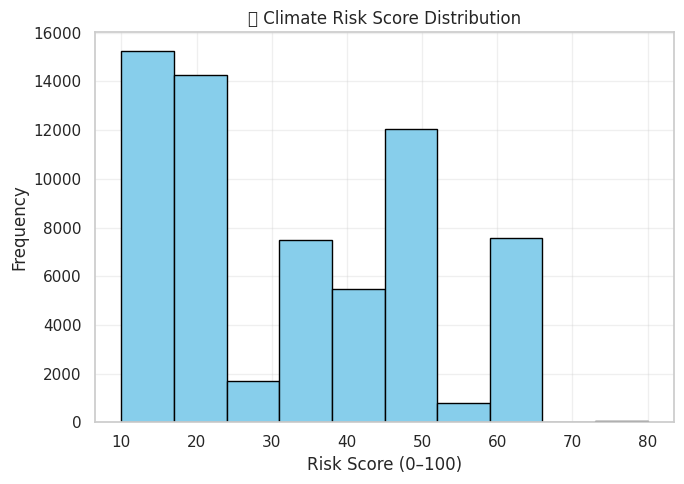

In [110]:


def plot_risk_score_distribution(df):

    if "Climate_Risk_Score" not in df.columns:
        raise ValueError("❌ Climate_Risk_Score column missing")

    plt.figure(figsize=(7,5))

    plt.hist(df["Climate_Risk_Score"], bins=10, color="skyblue", edgecolor="black")

    plt.title("🌍 Climate Risk Score Distribution")
    plt.xlabel("Risk Score (0–100)")
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_risk_score_distribution(df)


## RISK SCORE TREND 

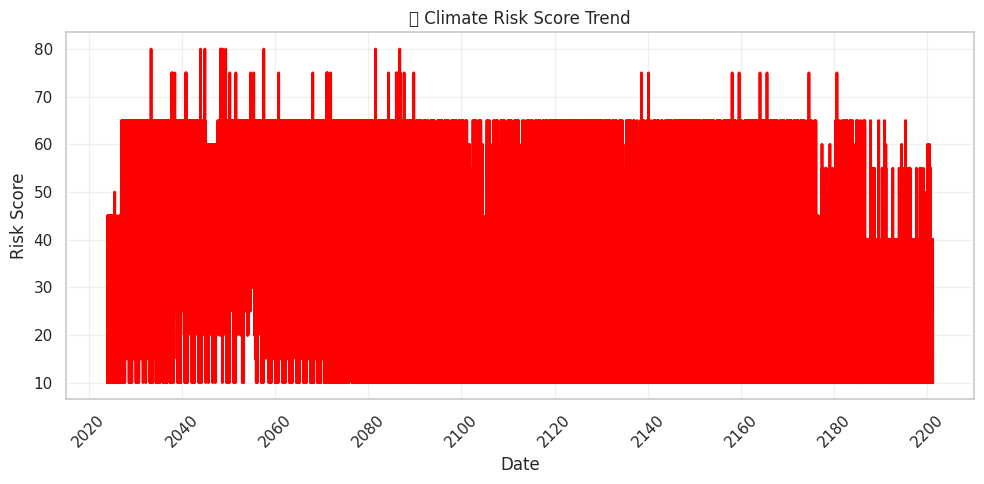

In [111]:
def plot_risk_score_trend(df):

    if "Climate_Risk_Score" not in df.columns:
        raise ValueError("❌ Climate_Risk_Score column missing")

    df = df.copy()

    # auto date if missing
    if "date" not in df.columns:
        df["date"] = pd.date_range(start="2024-01-01", periods=len(df), freq="D")

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    plt.figure(figsize=(10,5))

    plt.plot(
        df["date"],
        df["Climate_Risk_Score"],
        color="red",
        linewidth=2
    )

    plt.title("🌡️ Climate Risk Score Trend")
    plt.xlabel("Date")
    plt.ylabel("Risk Score")

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_risk_score_trend(df)

## RISK CATEGORY BREAKDOWN (LOW / MEDIUM / HIGH) 

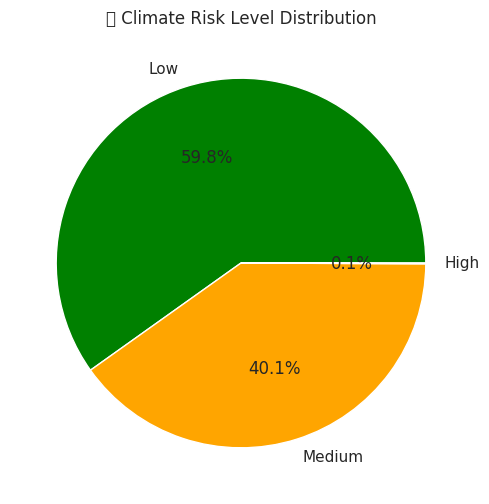

In [112]:
def plot_risk_categories(df):

    if "Climate_Risk_Score" not in df.columns:
        raise ValueError("❌ Climate_Risk_Score column missing")

    def categorize(score):
        if score < 40:
            return "Low"
        elif score < 70:
            return "Medium"
        else:
            return "High"

    df = df.copy()
    df["Risk_Level"] = df["Climate_Risk_Score"].apply(categorize)

    plt.figure(figsize=(6,6))

    df["Risk_Level"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        colors=["green", "orange", "red"]
    )

    plt.title("🌍 Climate Risk Level Distribution")
    plt.ylabel("")
    plt.show()
plot_risk_categories(df)

## BOX PLOT 

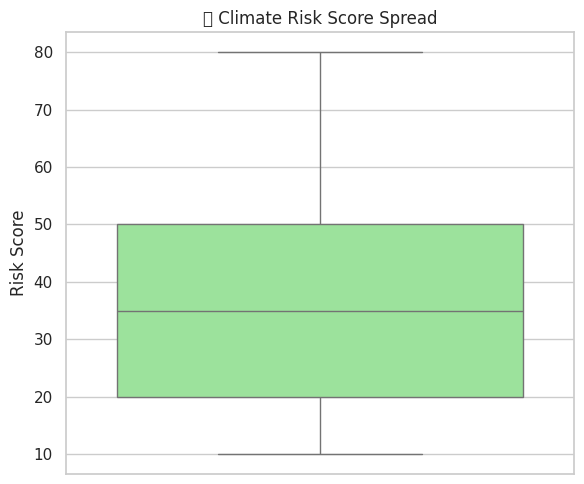

In [113]:
plt.rcParams["font.family"] = "DejaVu Sans"

def plot_risk_boxplot(df):

    if "Climate_Risk_Score" not in df.columns:
        raise ValueError("❌ Climate_Risk_Score column missing")

    plt.figure(figsize=(6,5))

    sns.boxplot(y=df["Climate_Risk_Score"], color="lightgreen")

    plt.title("🌍 Climate Risk Score Spread")
    plt.ylabel("Risk Score")

    plt.tight_layout()
    plt.show()
plot_risk_boxplot(df)